In [2]:
import pandas as pd
from datetime import datetime
from google.colab import files
uploaded = files.upload()
# read txt file
with open("synthetic_logs_10000.txt", "r") as f:
    logs = f.readlines()

print("Total logs:", len(logs))
print(logs[:5])

Saving synthetic_logs_10000.txt to synthetic_logs_10000.txt
Total logs: 10000
['2025-01-01 10:00:01 MANAGER: Configuration saved on host1\n', '2025-01-01 10:00:01 OSPF: Neighbor changed state to DOWN on host8\n', '2025-01-01 10:00:03 SECURITY: possible port scan detected from 221.130.12.125\n', '2025-01-01 10:00:03 OSPF: Neighbor changed state to DOWN on host4\n', '2025-01-01 10:00:04 DB: Database connection timeout on host7\n']


In [3]:
data = []

for i, log in enumerate(logs):
    parts = log.strip().split(" ", 2)

    timestamp_str = parts[0] + " " + parts[1]
    message = parts[2]

    # extract source_type (before colon)
    source_type = message.split(":")[0]

    data.append({
        "sequence_number": i,
        "timestamp": pd.to_datetime(timestamp_str),
        "source_type": source_type,
        "message": message
    })

df = pd.DataFrame(data)
df = df.sort_values("timestamp")

df.head()

,sequence_number,timestamp,source_type,message
0,0,2025-01-01 10:00:01,MANAGER,MANAGER: Configuration saved on host1
1,1,2025-01-01 10:00:01,OSPF,OSPF: Neighbor changed state to DOWN on host8
2,2,2025-01-01 10:00:03,SECURITY,SECURITY: possible port scan detected from 221...
3,3,2025-01-01 10:00:03,OSPF,OSPF: Neighbor changed state to DOWN on host4
4,4,2025-01-01 10:00:04,DB,DB: Database connection timeout on host7


In [4]:
# compute time difference between logs
df["time_diff"] = df["timestamp"].diff().dt.total_seconds()

# create session (gap > 60 sec = new session)
df["session_id"] = (df["time_diff"] > 60).cumsum()

df[["timestamp", "session_id"]].head(10)

,timestamp,session_id
0,2025-01-01 10:00:01,0
1,2025-01-01 10:00:01,0
2,2025-01-01 10:00:03,0
3,2025-01-01 10:00:03,0
4,2025-01-01 10:00:04,0
5,2025-01-01 10:00:06,0
6,2025-01-01 10:00:07,0
7,2025-01-01 10:00:08,0
8,2025-01-01 10:00:09,0
9,2025-01-01 10:00:10,0


In [5]:
import re

def extract_template(message):
    # remove IPs
    message = re.sub(r"\d+\.\d+\.\d+\.\d+", "<IP>", message)

    # remove numbers
    message = re.sub(r"\d+", "<NUM>", message)

    return message

df["template"] = df["message"].apply(extract_template)

df[["message", "template"]].head()

,message,template
0,MANAGER: Configuration saved on host1,MANAGER: Configuration saved on host<NUM>
1,OSPF: Neighbor changed state to DOWN on host8,OSPF: Neighbor changed state to DOWN on host<NUM>
2,SECURITY: possible port scan detected from 221...,SECURITY: possible port scan detected from <IP>
3,OSPF: Neighbor changed state to DOWN on host4,OSPF: Neighbor changed state to DOWN on host<NUM>
4,DB: Database connection timeout on host7,DB: Database connection timeout on host<NUM>


In [6]:
template_counts = df["template"].value_counts()

# keep templates appearing more than threshold
threshold = 20
frequent_templates = template_counts[template_counts > threshold].index

df_filtered = df[df["template"].isin(frequent_templates)]

In [7]:
grouped = (
    df_filtered
    .groupby(["session_id", "template"])
    .size()
    .reset_index(name="frequency")
)

grouped.head()

,session_id,template,frequency
0,0,CPU: High CPU usage detected on host<NUM>,1161
1,0,DB: Database connection timeout on host<NUM>,1017
2,0,DHCP_SNOOP: packet dropped from <IP>,1129
3,0,MANAGER: Configuration saved on host<NUM>,1102
4,0,OSPF: Neighbor changed state to DOWN on host<NUM>,1158


In [8]:
import numpy as np

grouped["rarity"] = 1 / np.log(grouped["frequency"] + 2)

In [9]:
mean = grouped["frequency"].mean()
std = grouped["frequency"].std()

grouped["deviation"] = (grouped["frequency"] - mean) / (std + 1e-5)

In [10]:
grouped["event_weight"] = (
    0.6 * grouped["rarity"] +
    0.4 * grouped["deviation"]
)

In [13]:
X = grouped[["frequency", "event_weight"]].values

print("X shape:", X.shape)

X shape: (9, 2)


In [14]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model.fit(X)

IsolationForest(contamination=0.05, random_state=42)

In [15]:
grouped["anomaly_score"] = model.decision_function(X)
grouped["anomaly"] = model.predict(X)

grouped.sort_values("anomaly_score").head(10)

,session_id,template,frequency,rarity,deviation,event_weight,anomaly_score,anomaly
1,0,DB: Database connection timeout on host<NUM>,1017,0.144371,-2.066574,-0.740007,-0.081187,-1
7,0,SNMP: Authentication failure from <IP>,1077,0.143189,-0.749042,-0.213703,0.121781,1
0,0,CPU: High CPU usage detected on host<NUM>,1161,0.141668,1.095504,0.523202,0.148492,1
4,0,OSPF: Neighbor changed state to DOWN on host<NUM>,1158,0.141720,1.029627,0.496883,0.164504,1
5,0,PORT: Port <NUM> changed state to DOWN on host...,1143,0.141982,0.700244,0.365287,0.165262,1
3,0,MANAGER: Configuration saved on host<NUM>,1102,0.142721,-0.200070,0.005604,0.184548,1
6,0,SECURITY: possible port scan detected from <IP>,1121,0.142374,0.217149,0.172284,0.185093,1
8,0,VLAN: VLAN <NUM> added on host<NUM>,1092,0.142906,-0.419658,-0.082120,0.189232,1
2,0,DHCP_SNOOP: packet dropped from <IP>,1129,0.142230,0.392820,0.242466,0.191696,1


In [16]:
anomalies = grouped[grouped["anomaly"] == -1]

print("Top anomalies:")
anomalies.sort_values("anomaly_score").head(10)

Top anomalies:


,session_id,template,frequency,rarity,deviation,event_weight,anomaly_score,anomaly
1,0,DB: Database connection timeout on host<NUM>,1017,0.144371,-2.066574,-0.740007,-0.081187,-1


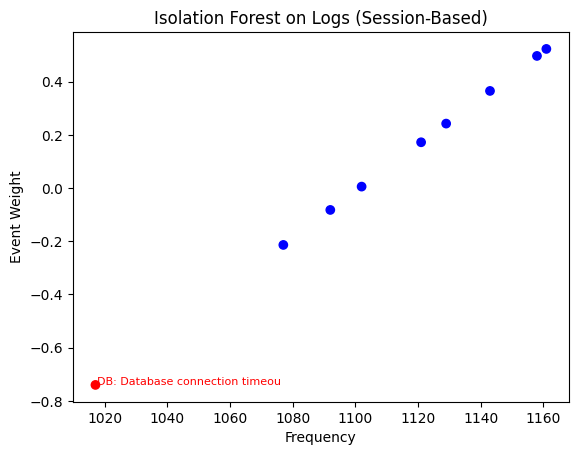

In [17]:
import matplotlib.pyplot as plt

colors = grouped["anomaly"].map({1: "blue", -1: "red"})

plt.scatter(grouped["frequency"], grouped["event_weight"], c=colors)

# label anomalies
for _, row in grouped.iterrows():
    if row["anomaly"] == -1:
        plt.text(
            row["frequency"] + 0.5,
            row["event_weight"],
            row["template"][:30],
            fontsize=8,
            color='red'
        )

plt.xlabel("Frequency")
plt.ylabel("Event Weight")
plt.title("Isolation Forest on Logs (Session-Based)")
plt.show()